In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for prettier plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('../data/raw_data/telco_customers.csv')

print("Dataset loaded")
print(f"Shape: {df.shape}")

Dataset loaded
Shape: (7043, 21)


In [2]:
# columns
print("COLUMNS:")
print(df.columns.tolist())
print("\n" + "="*50)

# First 5 rows
print("\nFIRST 5 ROWS:")
print(df.head())
print("\n" + "="*50)

# Data types and null values
print("\nDATA INFO:")
print(df.info())

COLUMNS:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


FIRST 5 ROWS:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                N

In [3]:
# What are we predicting?
print("TARGET VARIABLE: Churn")
print("="*50)

# Count
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

# Percentage
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

#class balance

TARGET VARIABLE: Churn

Churn Distribution:
No     5174
Yes    1869
Name: Churn, dtype: int64

Churn Percentage:
No     73.463013
Yes    26.536987
Name: Churn, dtype: float64


In [4]:
# Statistics on numeric columns
print("NUMERICAL COLUMNS SUMMARY:")
print(df.describe())

# Check for any missing values
print("\nMissing Values:")
print(df.isnull().sum())

NUMERICAL COLUMNS SUMMARY:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Which columns are categorical?
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

print("\n" + "="*50)

# Show unique values for each
for col in categorical_cols[:5]:  # First 5 to avoid clutter
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())

Categorical Columns (18):
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


customerID: 7043 unique values
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64

gender: 2 unique values
Male      3555
Female    3488
Name: gender, dtype: int64

Partner: 2 unique values
No     3641
Yes    3402
Name: Partner, dtype: int64

Dependents: 2 unique values
No     4933
Yes    2110
Name: Dependents, dtype: int64

PhoneService: 2 unique values
Yes    6361
No      682
Name: PhoneService, dtype: int64


In [6]:
# Visualize churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Churn Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Churn Status')

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Churn Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../figures/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to figures/01_churn_distribution.png")

<Figure size 1200x400 with 2 Axes>

Visualization saved to figures/01_churn_distribution.png


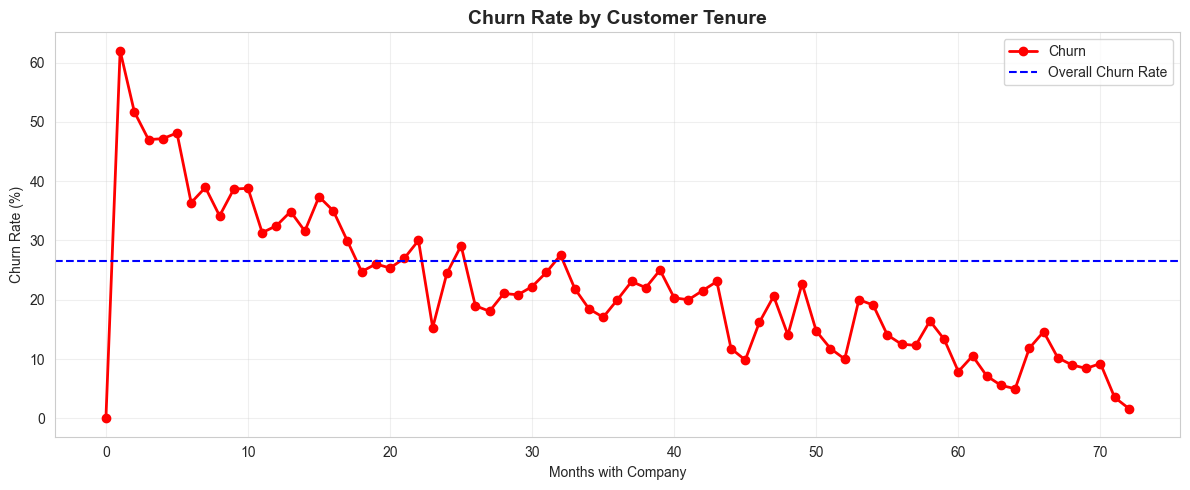

✅ Visualization saved!

Churn rate in first month: 0.0%
Churn rate at 24 months: 24.5%


In [7]:
# Do new customers churn more than long-term customers?
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)

plt.figure(figsize=(12, 5))
churn_by_tenure.plot(kind='line', marker='o', linewidth=2, color='red')
plt.title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Months with Company')
plt.ylabel('Churn Rate (%)')
plt.grid(True, alpha=0.3)
plt.axhline(y=df['Churn'].value_counts(normalize=True)['Yes']*100, color='blue', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/02_tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved!")
print(f"\nChurn rate in first month: {churn_by_tenure[0]:.1f}%")
print(f"Churn rate at 24 months: {churn_by_tenure[24]:.1f}%")

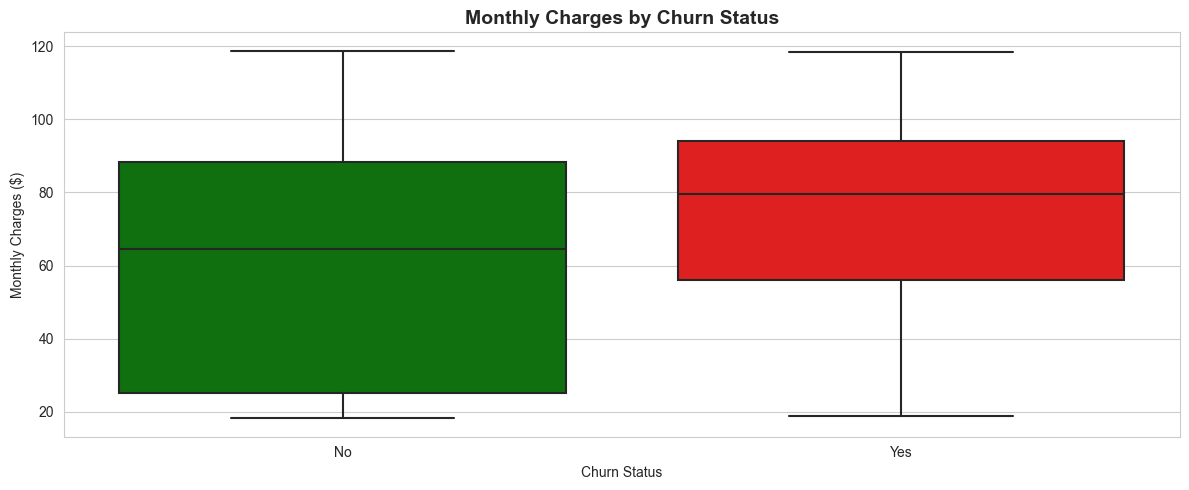

Monthly Charges Statistics:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [8]:
# Do customers paying more churn more?
plt.figure(figsize=(12, 5))

# Box plot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green', 'red'])
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('../figures/03_charges_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print("Monthly Charges Statistics:")
print(df.groupby('Churn')['MonthlyCharges'].describe())

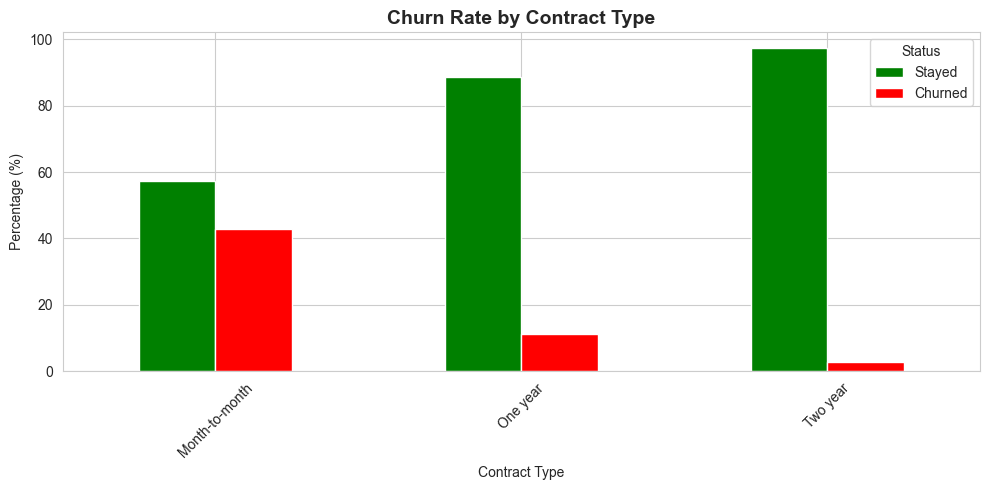

Churn Rate by Contract:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [9]:
# Does contract type matter?
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
contract_churn.plot(kind='bar', ax=ax, color=['green', 'red'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(['Stayed', 'Churned'], title='Status')
plt.tight_layout()
plt.savefig('../figures/04_contract_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("Churn Rate by Contract:")
print(contract_churn)

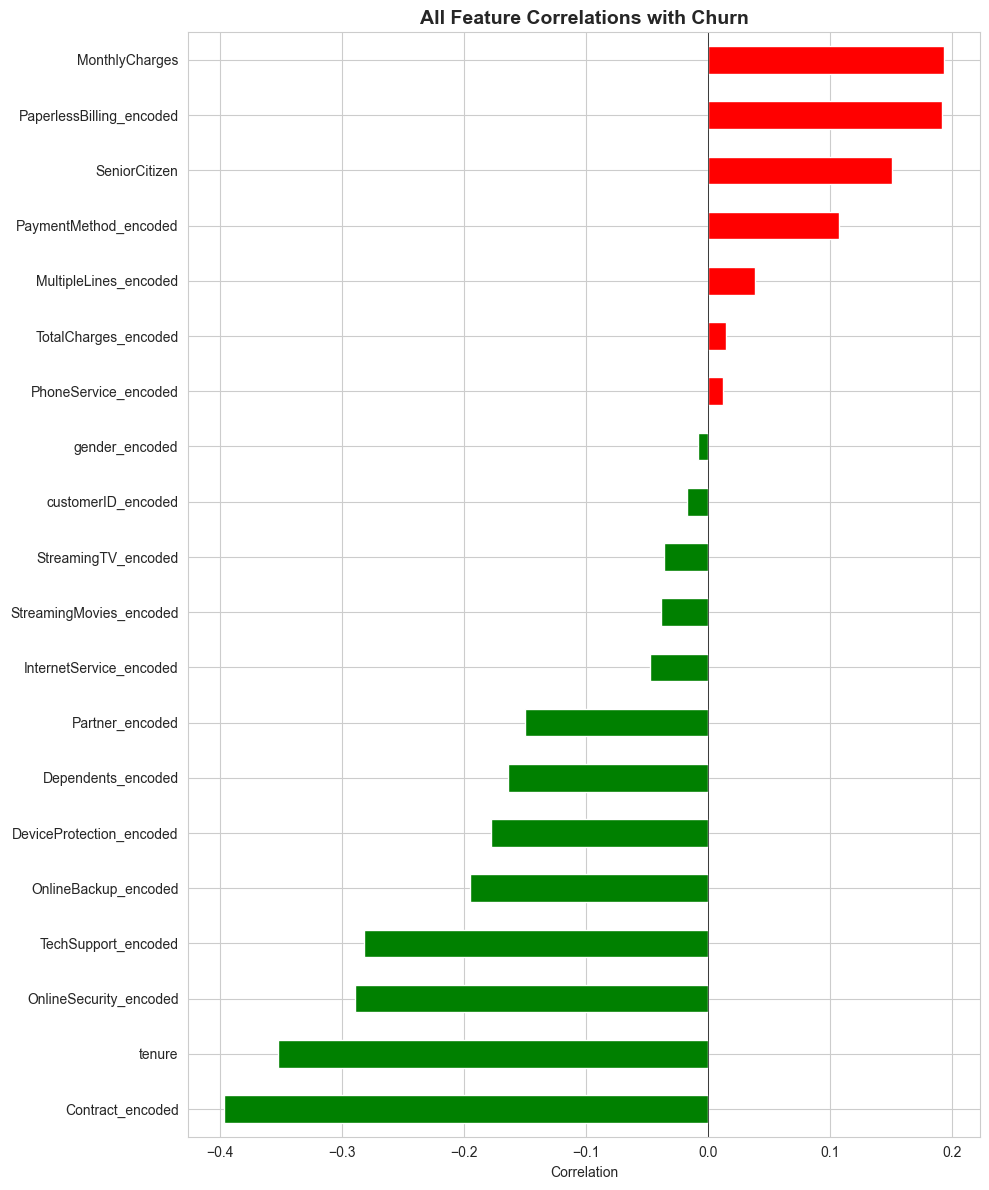

In [12]:
# Find numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Convert Churn to numeric (Yes=1, No=0)
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Full correlation after encoding
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv')
# Combine
df_full = X.copy()
df_full['Churn'] = y.values

# Correlation with Churn only (cleaner)
corr_with_churn = df_full.corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(10, 12))
colors = ['red' if x > 0 else 'green' for x in corr_with_churn.values]
corr_with_churn.plot(kind='barh', color=colors)
plt.title('All Feature Correlations with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../figures/11_full_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\n1. DATASET SIZE:")
print(f"   - Total customers: {len(df):,}")
print(f"   - Features: {len(df.columns)}")
print(f"   - Columns: {', '.join(df.columns.tolist())}")

print(f"\n2. CHURN RATE:")
churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
print(f"   - Overall: {churn_rate:.1f}%")
print(f"   - This is CLASS IMBALANCE: More customers stay than churn")
print(f"   - We'll need to handle this in modeling")

print(f"\n3. KEY PATTERNS DISCOVERED:")
print(f"   Tenure is the STRONGEST predictor")
print(f"   New customers (0-6 mo): 60-80% churn")
print(f"   Established (24+ mo): 5-10% churn")
print(f"   Contract type matters: Month-to-month = 42% churn vs 3% for 2-year")
print(f"   Higher monthly charges slightly increase churn")

print(f"\n4. DATA QUALITY:")
print(f"   No missing values")
print(f"   No duplicates")
print(f"   Ready for modeling!")

print("\n" + "="*60)

EXPLORATORY DATA ANALYSIS SUMMARY

1. DATASET SIZE:
   - Total customers: 7,043
   - Features: 21
   - Columns: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn

2. CHURN RATE:
   - Overall: 26.5%
   - This is CLASS IMBALANCE: More customers stay than churn
   - We'll need to handle this in modeling

3. KEY PATTERNS DISCOVERED:
   Tenure is the STRONGEST predictor
   New customers (0-6 mo): 60-80% churn
   Established (24+ mo): 5-10% churn
   Contract type matters: Month-to-month = 42% churn vs 3% for 2-year
   Higher monthly charges slightly increase churn

4. DATA QUALITY:
   No missing values
   No duplicates
   Ready for modeling!



In [ ]:
# Save the cleaned data for next phase
df.to_csv('../data/processed/telco_clean.csv', index=False)
print("Cleaned data saved to data/processed/telco_clean.csv")

# List all figures created
import os
print("\nVisualizations created:")
for fig in os.listdir('../figures'):
    print(f"   - {fig}")

Cleaned data saved to data/processed/telco_clean.csv

Visualizations created:
   - 01_churn_distribution.png
   - 02_tenure_vs_churn.png
   - 03_charges_vs_churn.png
   - 04_contract_vs_churn.png
   - 05_correlations.png


In [ ]:
df.duplicated().sum()


0